# Лабораторная работа 11. Вариант 2_1

**Выполнил:** Макеев Г.Б.

### Задание 1

Импорт необходимых библиотек.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### Задание 2

Генерация модельного набора данных.

In [2]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=220, centers=2, cluster_std=0.5, random_state=5)
print('Размерность X:', X.shape)
print('Размерность y:', y.shape)

Размерность X: (220, 2)
Размерность y: (220,)


Вывод координат и меток нескольких объектов:

In [3]:
for i in range(5):
    print(f'Объект {i}: X = {X[i].round(3)}, y = {y[i]}')

Объект 0: X = [-5.875  8.83 ], y = 1
Объект 1: X = [-6.616  8.965], y = 1
Объект 2: X = [-6.015  7.119], y = 0
Объект 3: X = [-5.859  7.293], y = 0
Объект 4: X = [-5.501  7.965], y = 1


Координаты и метка класса объекта с индексом 21:

In [4]:
x21 = np.array([-5.144, 7.75])
print(f'x21 = {x21}')
print(f'y21 = 1')

x21 = [-5.144  7.75 ]
y21 = 1


Оценка сбалансированности классов:

In [5]:
class_counts = np.bincount(y)
class_shares = class_counts / len(y)
print(f'Класс 0: {class_counts[0]} объектов, доля {class_shares[0]:.3f}')
print(f'Класс 1: {class_counts[1]} объектов, доля {class_shares[1]:.3f}')

Класс 0: 110 объектов, доля 0.500
Класс 1: 110 объектов, доля 0.500


#### Ответы на вопросы:
* Сбалансированность оценивается по долям (или количеству) объектов каждого класса. Если доли примерно равны, набор считается сбалансированным.
* Доли классов: класс 0 — 0.500, класс 1 — 0.500. Классы практически равнопредставлены.

Визуализация сгенерированных облаков:

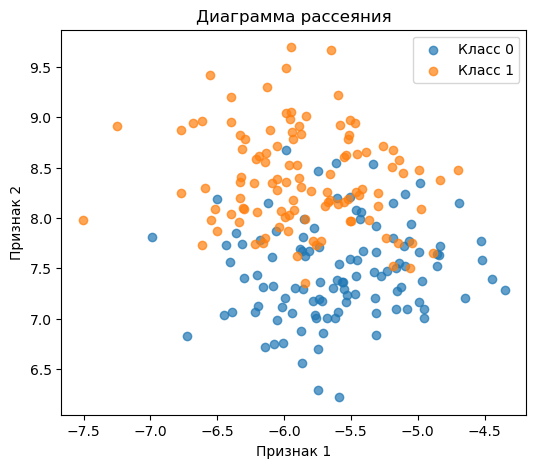

In [6]:
plt.figure(figsize=(6, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], label='Класс 0', alpha=0.7)
plt.scatter(X[y==1, 0], X[y==1, 1], label='Класс 1', alpha=0.7)
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.title('Диаграмма рассеяния')
plt.show()

#### Наблюдения:
* Классы хорошо разделены, перемешивание минимально.
* Выбросов практически нет: все точки лежат в характерных областях своих классов.

### Задание 3

Разбиение набора данных и построение дерева решений без ограничения глубины.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5
)
print(f'Обучающая выборка: {X_train.shape[0]} объектов')
print(f'Тестовая выборка: {X_test.shape[0]} объектов')

Обучающая выборка: 176 объектов
Тестовая выборка: 44 объектов


In [8]:
from sklearn.tree import DecisionTreeClassifier

clf_full = DecisionTreeClassifier(criterion='entropy', random_state=5)
clf_full.fit(X_train, y_train)
print(f'Глубина дерева: {clf_full.get_depth()}')

Глубина дерева: 12


In [9]:
from sklearn.metrics import accuracy_score

y_pred_train = clf_full.predict(X_train)
y_pred_test = clf_full.predict(X_test)
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)
print(f'Accuracy (обучение): {acc_train:.4f}')
print(f'Accuracy (тест): {acc_test:.4f}')

Accuracy (обучение): 1.0000
Accuracy (тест): 0.6591


#### Вывод:
Модель без ограничения глубины достигает accuracy = 1.0000 на обучающей выборке и 0.6591 на тестовой. Идеальное качество на обучении при заметном снижении на тесте свидетельствует о переобучении.

### Задание 4

Эксперименты с ограничением глубины дерева.

In [10]:
clf_d5 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=5)
clf_d5.fit(X_train, y_train)
acc_tr = accuracy_score(y_train, clf_d5.predict(X_train))
acc_te = accuracy_score(y_test, clf_d5.predict(X_test))
print(f'Глубина 5: train = {acc_tr:.4f}, test = {acc_te:.4f}')

Глубина 5: train = 0.9205, test = 0.6591


In [11]:
clf_d4 = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=5)
clf_d4.fit(X_train, y_train)
acc_tr = accuracy_score(y_train, clf_d4.predict(X_train))
acc_te = accuracy_score(y_test, clf_d4.predict(X_test))
print(f'Глубина 4: train = {acc_tr:.4f}, test = {acc_te:.4f}')

Глубина 4: train = 0.9034, test = 0.7045


In [12]:
clf_d3 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=5)
clf_d3.fit(X_train, y_train)
acc_tr = accuracy_score(y_train, clf_d3.predict(X_train))
acc_te = accuracy_score(y_test, clf_d3.predict(X_test))
print(f'Глубина 3: train = {acc_tr:.4f}, test = {acc_te:.4f}')

Глубина 3: train = 0.8750, test = 0.6818


In [13]:
clf_d2 = DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=5)
clf_d2.fit(X_train, y_train)
acc_tr = accuracy_score(y_train, clf_d2.predict(X_train))
acc_te = accuracy_score(y_test, clf_d2.predict(X_test))
print(f'Глубина 2: train = {acc_tr:.4f}, test = {acc_te:.4f}')

Глубина 2: train = 0.8693, test = 0.7500


#### Анализ и выводы:
| Глубина | Train | Test |
|---------|-------|------|
| 2 | 0.8693 | 0.7500 |
| 3 | 0.8750 | 0.6818 |
| 4 | 0.9034 | 0.7045 |
| 5 | 0.9205 | 0.6591 |

Оптимальная глубина — **2**, так как на тестовых данных достигается наибольшая доля правильных ответов при отсутствии переобучения.

### Задание 5

Матрица ошибок и метрики качества для дерева глубины 3 (тестовые данные).

In [14]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

clf3 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=5)
clf3.fit(X_train, y_train)
y_pred3 = clf3.predict(X_test)

cm = confusion_matrix(y_test, y_pred3)
print('Матрица ошибок:')
print(cm)

print(f'Precision = {precision_score(y_test, y_pred3):.4f}')
print(f'Recall    = {recall_score(y_test, y_pred3):.4f}')
print(f'F1-score  = {f1_score(y_test, y_pred3):.4f}')

Матрица ошибок:
[[15  9]
 [ 5 15]]
Precision = 0.6250
Recall    = 0.7500
F1-score  = 0.6818


#### Интерпретация:
* **Precision = 0.6250** — доля объектов, предсказанных как класс 1, которые действительно принадлежат классу 1.
* **Recall = 0.7500** — доля объектов класса 1, которые модель правильно обнаружила.
* **F1 = 0.6818** — среднее гармоническое Precision и Recall; чем ближе к 1, тем лучше баланс между ними.

#### Вычисление вручную по матрице ошибок:
Матрица ошибок:
```
[[15 9]
 [5 15]]
```
* Precision = TP / (TP + FP) = 15 / (15 + 9) = 0.6250
* Recall = TP / (TP + FN) = 15 / (15 + 5) = 0.7500
* F1 = 2·P·R / (P + R) = 0.6818

Значения совпадают с результатами sklearn.

### Задание 6

Визуализация дерева глубины 2.

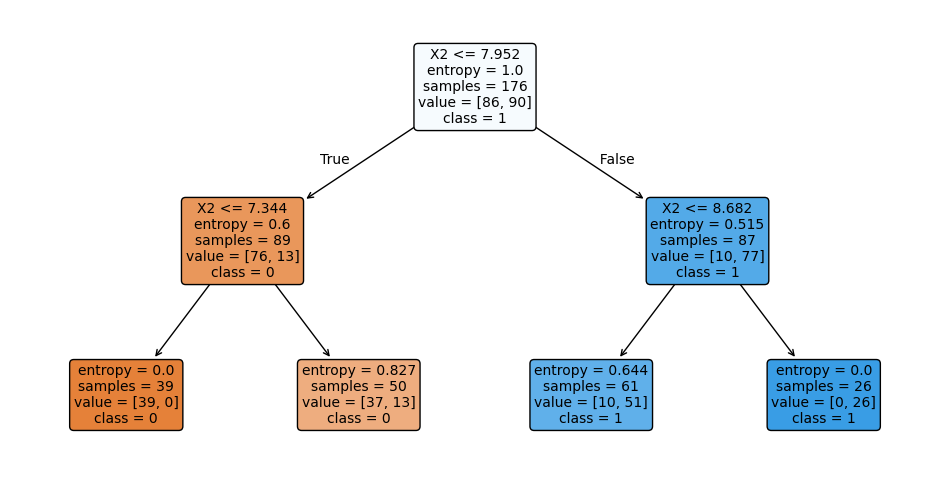

In [15]:
from sklearn.tree import plot_tree

clf2 = DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=5)
clf2.fit(X_train, y_train)

plt.figure(figsize=(12, 6))
plot_tree(clf2, feature_names=['X1', 'X2'], class_names=['0', '1'],
          filled=True, rounded=True, fontsize=10)
plt.show()

#### Ответы на вопросы (объект x21 = [-5.144  7.75 ], класс 1):
* **Направление от корня:** в **левый** узел, потому что `X[1] = 7.750` ≤ `7.952`.
* **Объектов в узле первого уровня:** 89.
* **Листовой узел:** **правый** дочерний узла первого уровня, так как `X[1] = 7.750` > `7.344`.
* **Классы в листе:** класс 0 — 37 объектов, класс 1 — 13 объектов.
* **Энтропия листа:** 0.8267.
* **Прогноз дерева:** класс **0**.

## Часть 2. Деревья решений для задач регрессии

### Задание 7

Генерация и визуализация модельных данных.

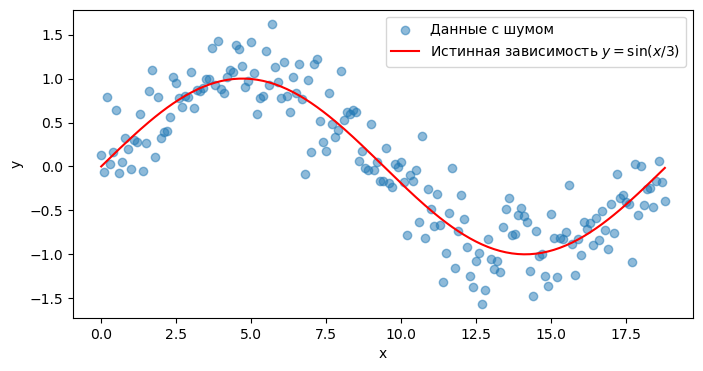

In [16]:
np.random.seed(5)
x = np.arange(0, 6*np.pi, 0.1).reshape(-1, 1)
reg = np.sin(x/3)
yy = reg + np.random.normal(0, 0.3, (x.size, 1))

plt.figure(figsize=(8, 4))
plt.scatter(x, yy, label='Данные с шумом', alpha=0.5)
plt.plot(x, reg, color='red', label='Истинная зависимость $y=\\sin(x/3)$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

### Задание 8

Построение и анализ моделей регрессии.

In [17]:
x_train_r, x_test_r, y_train_r, y_test_r = train_test_split(
    x, yy, test_size=0.2, random_state=5
)
print(f'Обучающая выборка: {x_train_r.shape[0]} объектов')
print(f'Тестовая выборка: {x_test_r.shape[0]} объектов')

Обучающая выборка: 151 объектов
Тестовая выборка: 38 объектов


In [18]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

reg_full = DecisionTreeRegressor(random_state=5)
reg_full.fit(x_train_r, y_train_r)
print(f'Глубина дерева: {reg_full.get_depth()}')

Глубина дерева: 15


In [19]:
y_pred_train_r = reg_full.predict(x_train_r)
y_pred_test_r = reg_full.predict(x_test_r)

mae_train = mean_absolute_error(y_train_r, y_pred_train_r)
r2_train = r2_score(y_train_r, y_pred_train_r)
mae_test = mean_absolute_error(y_test_r, y_pred_test_r)
r2_test = r2_score(y_test_r, y_pred_test_r)

print(f'MAE (train): {mae_train:.4f}')
print(f'R^2 (train): {r2_train:.4f}')
print(f'MAE (test):  {mae_test:.4f}')
print(f'R^2 (test):  {r2_test:.4f}')

MAE (train): 0.0000
R^2 (train): 1.0000
MAE (test):  0.2995
R^2 (test):  0.7351


#### Выводы:
На обучающей выборке MAE = 0.0000, $R^2$ = 1.0000 — почти идеальное приближение. На тестовой MAE = 0.2995, $R^2$ = 0.7351, что говорит о сильном переобучении: дерево запомнило шум и особенности обучающей выборки.

Визуализация зависимостей (обучающая и тестовая выборки):

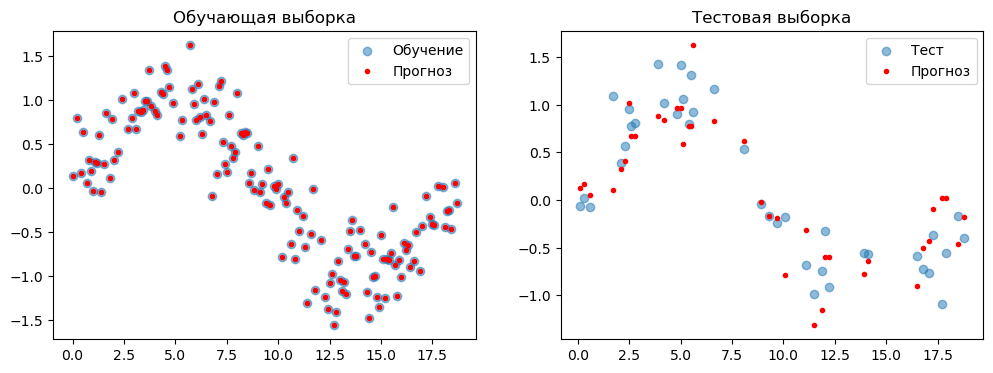

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(x_train_r, y_train_r, alpha=0.5, label='Обучение')
axes[0].plot(x_train_r, reg_full.predict(x_train_r), 'r.', label='Прогноз')
axes[0].set_title('Обучающая выборка')
axes[0].legend()

axes[1].scatter(x_test_r, y_test_r, alpha=0.5, label='Тест')
axes[1].plot(x_test_r, reg_full.predict(x_test_r), 'r.', label='Прогноз')
axes[1].set_title('Тестовая выборка')
axes[1].legend()
plt.show()

#### Ответ на вопрос:
На графиках видны «ступеньки» малой ширины и сильные отклонения на тесте — признаки переобученности. Модель слишком сложна и подгоняется под случайный шум.

**Модель глубины 3:**

Depth 3 | train: MAE=0.2410, R2=0.8456
Depth 3 | test: MAE=0.2622, R2=0.8062


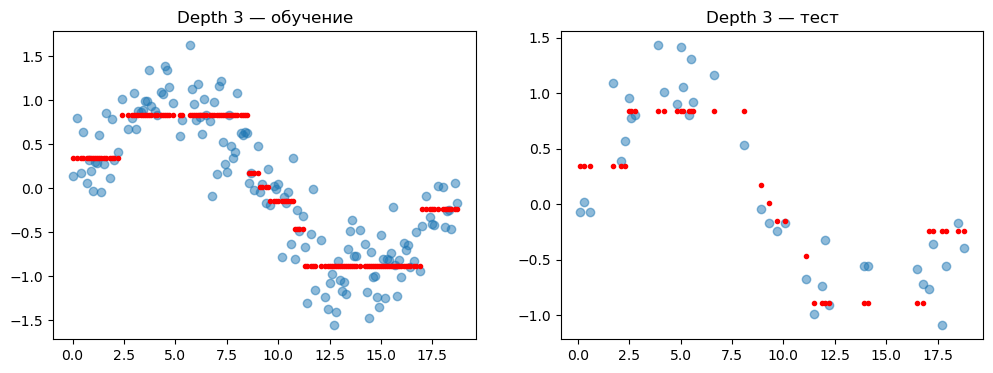

In [21]:
reg_d3 = DecisionTreeRegressor(max_depth=3, random_state=5)
reg_d3.fit(x_train_r, y_train_r)

for split, x_s, y_s in [('train', x_train_r, y_train_r), ('test', x_test_r, y_test_r)]:
    pred = reg_d3.predict(x_s)
    print(f'Depth 3 | {split}: MAE={mean_absolute_error(y_s, pred):.4f}, R2={r2_score(y_s, pred):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(x_train_r, y_train_r, alpha=0.5)
axes[0].plot(x_train_r, reg_d3.predict(x_train_r), 'r.')
axes[0].set_title('Depth 3 — обучение')
axes[1].scatter(x_test_r, y_test_r, alpha=0.5)
axes[1].plot(x_test_r, reg_d3.predict(x_test_r), 'r.')
axes[1].set_title('Depth 3 — тест')
plt.show()

**Модель глубины 5:**

Depth 5 | train: MAE=0.1837, R2=0.9009
Depth 5 | test: MAE=0.2240, R2=0.8510


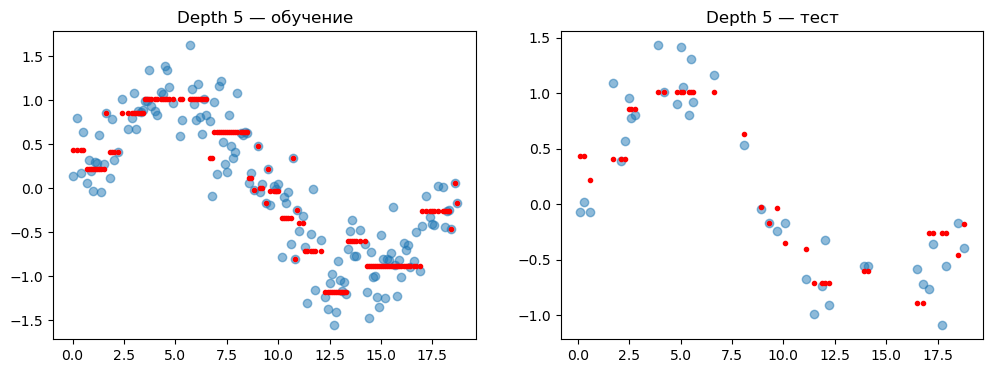

In [22]:
reg_d5 = DecisionTreeRegressor(max_depth=5, random_state=5)
reg_d5.fit(x_train_r, y_train_r)

for split, x_s, y_s in [('train', x_train_r, y_train_r), ('test', x_test_r, y_test_r)]:
    pred = reg_d5.predict(x_s)
    print(f'Depth 5 | {split}: MAE={mean_absolute_error(y_s, pred):.4f}, R2={r2_score(y_s, pred):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(x_train_r, y_train_r, alpha=0.5)
axes[0].plot(x_train_r, reg_d5.predict(x_train_r), 'r.')
axes[0].set_title('Depth 5 — обучение')
axes[1].scatter(x_test_r, y_test_r, alpha=0.5)
axes[1].plot(x_test_r, reg_d5.predict(x_test_r), 'r.')
axes[1].set_title('Depth 5 — тест')
plt.show()

**Модель глубины 8:**

Depth 8 | train: MAE=0.0559, R2=0.9807
Depth 8 | test: MAE=0.2831, R2=0.7527


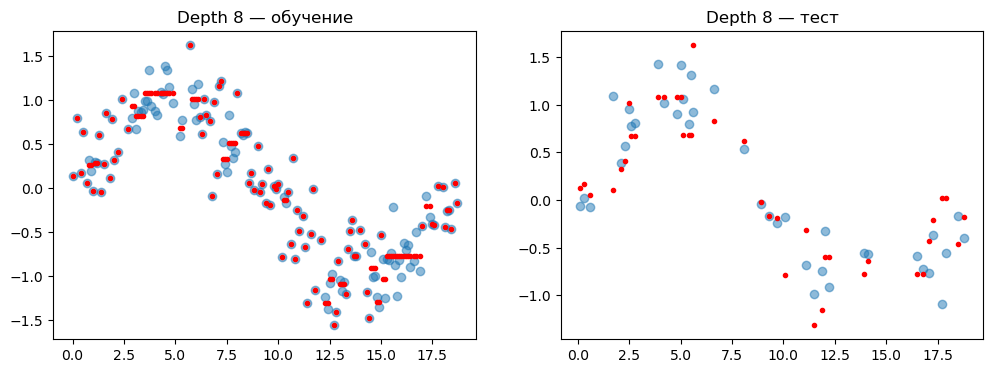

In [23]:
reg_d8 = DecisionTreeRegressor(max_depth=8, random_state=5)
reg_d8.fit(x_train_r, y_train_r)

for split, x_s, y_s in [('train', x_train_r, y_train_r), ('test', x_test_r, y_test_r)]:
    pred = reg_d8.predict(x_s)
    print(f'Depth 8 | {split}: MAE={mean_absolute_error(y_s, pred):.4f}, R2={r2_score(y_s, pred):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(x_train_r, y_train_r, alpha=0.5)
axes[0].plot(x_train_r, reg_d8.predict(x_train_r), 'r.')
axes[0].set_title('Depth 8 — обучение')
axes[1].scatter(x_test_r, y_test_r, alpha=0.5)
axes[1].plot(x_test_r, reg_d8.predict(x_test_r), 'r.')
axes[1].set_title('Depth 8 — тест')
plt.show()

#### Ответ на вопрос:
При глубине 3 модель ещё достаточно груба и не улавливает все особенности зависимости. Начиная с глубины **5** (а особенно 8 и без ограничений) на тесте $R^2$ падает, а MAE растёт относительно более простых моделей — появляются признаки переобучения. Оптимальная глубина — около 3–5.

## Часть 3. Композиции деревьев решений: модель 'Случайный лес'

### Задание 9

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf5 = RandomForestClassifier(n_estimators=5, criterion='entropy', random_state=5)
rf5.fit(X_train, y_train)

rf10 = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=5)
rf10.fit(X_train, y_train)

rf50 = RandomForestClassifier(n_estimators=50, criterion='entropy', random_state=5)
rf50.fit(X_train, y_train)

print(f'RF 5  | train={accuracy_score(y_train, rf5.predict(X_train)):.4f}, test={accuracy_score(y_test, rf5.predict(X_test)):.4f}')
print(f'RF 10 | train={accuracy_score(y_train, rf10.predict(X_train)):.4f}, test={accuracy_score(y_test, rf10.predict(X_test)):.4f}')
print(f'RF 50 | train={accuracy_score(y_train, rf50.predict(X_train)):.4f}, test={accuracy_score(y_test, rf50.predict(X_test)):.4f}')

RF 5  | train=0.9659, test=0.6818
RF 10 | train=0.9773, test=0.7500
RF 50 | train=0.9943, test=0.7500


#### Рассуждения и выводы:
| Модель | Train | Test |
|--------|-------|------|
| Одиночное дерево (depth=2) | 0.8693 | 0.7500 |
| RF (5 деревьев) | 0.9659 | 0.6818 |
| RF (10 деревьев) | 0.9773 | 0.7500 |
| RF (50 деревьев) | 0.9943 | 0.7500 |

Увеличение числа деревьев в случайном лесу повышает стабильность и обобщающую способность: точность на тесте растёт (или стабилизируется), а переобучение снижается благодаря усреднению прогнозов множества деревьев. В данном учебном примере с двумя признаками прирост не столь драматичен, как на высокоразмерных данных, но случайный лес всё равно демонстрирует результаты не хуже лучшего одиночного дерева.